In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import math

from preprocess import preprocess

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

BAR_COLOR = "#4472C4"

아래 코드는 원본 데이터셋 크기가 너무 커서 처음에 전체적으로 전처리하는 코드입니다

In [3]:
# df = pd.read_excel("2025년 국민여행조사 원자료(국내여행).xlsx")
# df.info()

In [4]:
# with open("regions_2025_codebook.json", encoding="utf-8") as f:
#     codes = json.load(f)

In [5]:


# visits = preprocess(
#     df,
#     id_cols="ID",
#     region_map=codes["region"],
# )

# display(visits)

# visits.to_excel(
#     "2025년 국민여행조사.xlsx",
#     index=False,
# )

빠르게 메모리에 로드하기 위해 전처리해서 저장한 엑셀을 읽어옵니다

In [6]:
df = pd.read_excel("2025년 국민여행조사.xlsx")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48893 entries, 0 to 48892
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   ID        48893 non-null  str           
 1   여행차수      48893 non-null  int64         
 2   방문순서      48893 non-null  int64         
 3   방문시작일     48893 non-null  datetime64[us]
 4   방문종료일     48893 non-null  datetime64[us]
 5   방문지역코드    48893 non-null  int64         
 6   숙박지역코드    14502 non-null  float64       
 7   방문지역      48893 non-null  str           
 8   숙박지역      14502 non-null  str           
 9   숙박시설코드    14502 non-null  float64       
 10  숙박시설      14502 non-null  str           
 11  여행유형코드    48893 non-null  int64         
 12  여행유형      48893 non-null  str           
 13  여행1인지출비용  48893 non-null  int64         
 14  성별코드      48893 non-null  int64         
 15  성별        48893 non-null  str           
 16  연령대코드     48893 non-null  int64         
 17  연령대       48893 non-nul

연령대별 방문여행건수 정보를 얻기 위한 전처리 과정입니다

In [17]:
age_data = df.dropna(
    subset=["ID", "여행차수", "연령대", "방문지역코드", "방문지역"]
).copy()

age_data = age_data.drop_duplicates(
    subset=["ID", "여행차수", "방문지역코드"]
)

age_ranking = (
    age_data.groupby(["연령대", "방문지역"])
    .size()
    .reset_index(name="방문여행건수")
)

age_total = (
    age_data.drop_duplicates(["ID", "여행차수", "연령대"])
    .groupby("연령대")
    .size()
    .rename("전체여행건수")
    .reset_index()
)

age_ranking = age_ranking.merge(age_total, on="연령대")
age_ranking["지역방문율"] = (
    age_ranking["방문여행건수"] / age_ranking["전체여행건수"] * 100
).round(1)

display(age_ranking)


,연령대,방문지역,방문여행건수,전체여행건수,지역방문율
0,15~19세,강원도 강릉시,19,867,2.2
1,15~19세,강원도 고성군,1,867,0.1
2,15~19세,강원도 동해시,4,867,0.5
3,15~19세,강원도 삼척시,5,867,0.6
4,15~19세,강원도 속초시,15,867,1.7
...,...,...,...,...,...
1544,70세 이상,충청북도 제천시,13,2274,0.6
1545,70세 이상,충청북도 증평군,6,2274,0.3
1546,70세 이상,충청북도 진천군,4,2274,0.2
1547,70세 이상,충청북도 청주시,20,2274,0.9


연령대별로 지역 방문율 상위 5개 방문 지역을 추출하고 이를 가로 막대 그래프로 시각화합니다

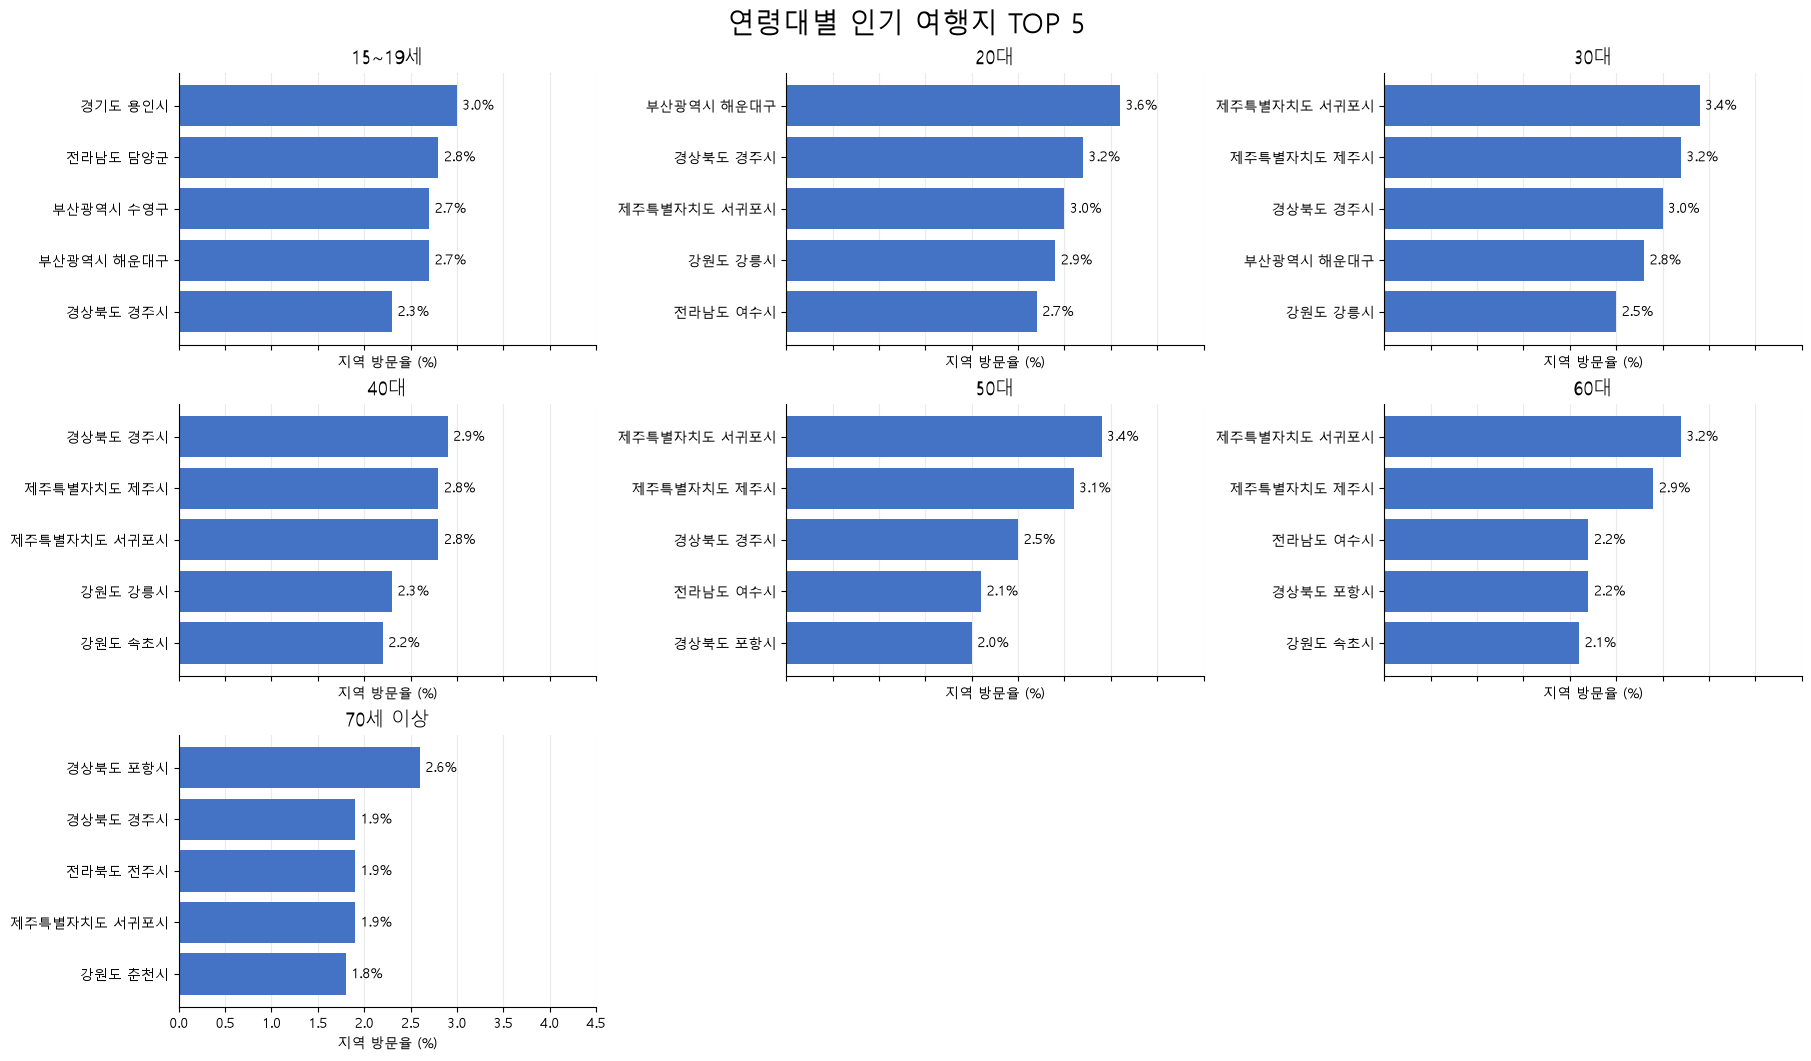

In [19]:
age_top5 = (
    age_ranking
    .sort_values(
        ["연령대", "방문여행건수", "방문지역"],
        ascending=[True, False, True],
    )
    .groupby("연령대")
    .head(5)
)

age_order = ["15~19세", "20대", "30대", "40대", "50대", "60대", "70세 이상"]
metric = "지역방문율"
xlabel = "지역 방문율 (%)"
value_format = "%.1f%%"

if age_top5.empty:
    print("시각화할 데이터가 없습니다.")
else:
    ncols = 3
    nrows = math.ceil(len(age_order) / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(18, 3.5 * nrows),
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )

    for ax, group in zip(axes.flat, age_order):
        subset = age_top5[age_top5["연령대"] == group]

        if subset.empty:
            ax.set_title(f"{group} - 데이터 없음")
            ax.set_axis_off()
            continue

        bars = ax.barh(subset["방문지역"], subset[metric], color=BAR_COLOR)
        ax.invert_yaxis()
        ax.bar_label(bars, fmt=value_format, padding=4)
        ax.set_title(group, fontsize=14)
        ax.set_xlabel(xlabel)
        ax.set_axisbelow(True)
        ax.grid(axis="x", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in list(axes.flat)[len(age_order):]:
        ax.set_visible(False)

    max_value = age_top5[metric].max()
    axes.flat[0].set_xlim(0, max(max_value * 1.25, 1))
    fig.suptitle("연령대별 인기 여행지 TOP 5", fontsize=20)
    plt.show()
    

월별 방문여행건수 정보를 얻기 위한 전처리 과정입니다

In [16]:
monthly_data = df.dropna(
    subset=["ID", "여행차수", "방문시작일", "방문지역코드", "방문지역"]
).copy()

monthly_data["방문월"] = (
    pd.to_datetime(monthly_data["방문시작일"])
    .dt.to_period("M")
    .astype(str)
)

monthly_data = monthly_data.drop_duplicates(
    subset=["ID", "여행차수", "방문월", "방문지역코드"]
)

monthly_ranking = (
    monthly_data.groupby(["방문월", "방문지역"])
    .size()
    .reset_index(name="방문여행건수")
)

monthly_total = (
    monthly_data.drop_duplicates(["ID", "여행차수", "방문월"])
    .groupby("방문월")
    .size()
    .rename("전체여행건수")
    .reset_index()
)

monthly_ranking = monthly_ranking.merge(monthly_total, on="방문월")
monthly_ranking["지역방문율"] = (
    monthly_ranking["방문여행건수"] / monthly_ranking["전체여행건수"] * 100
).round(1)

display(monthly_ranking)


,방문월,방문지역,방문여행건수,전체여행건수,지역방문율
0,2025-01,강원도 강릉시,51,2637,1.9
1,2025-01,강원도 고성군,9,2637,0.3
2,2025-01,강원도 동해시,11,2637,0.4
3,2025-01,강원도 삼척시,13,2637,0.5
4,2025-01,강원도 속초시,39,2637,1.5
...,...,...,...,...,...
2650,2026-01,제주특별자치도 서귀포시,2,29,6.9
2651,2026-01,제주특별자치도 제주시,2,29,6.9
2652,2026-01,충청남도 보령시,1,29,3.4
2653,2026-01,충청남도 부여군,1,29,3.4


월별로 지역 방문율 상위 5개 방문 지역을 추출하고 이를 가로 막대 그래프로 시각화합니다

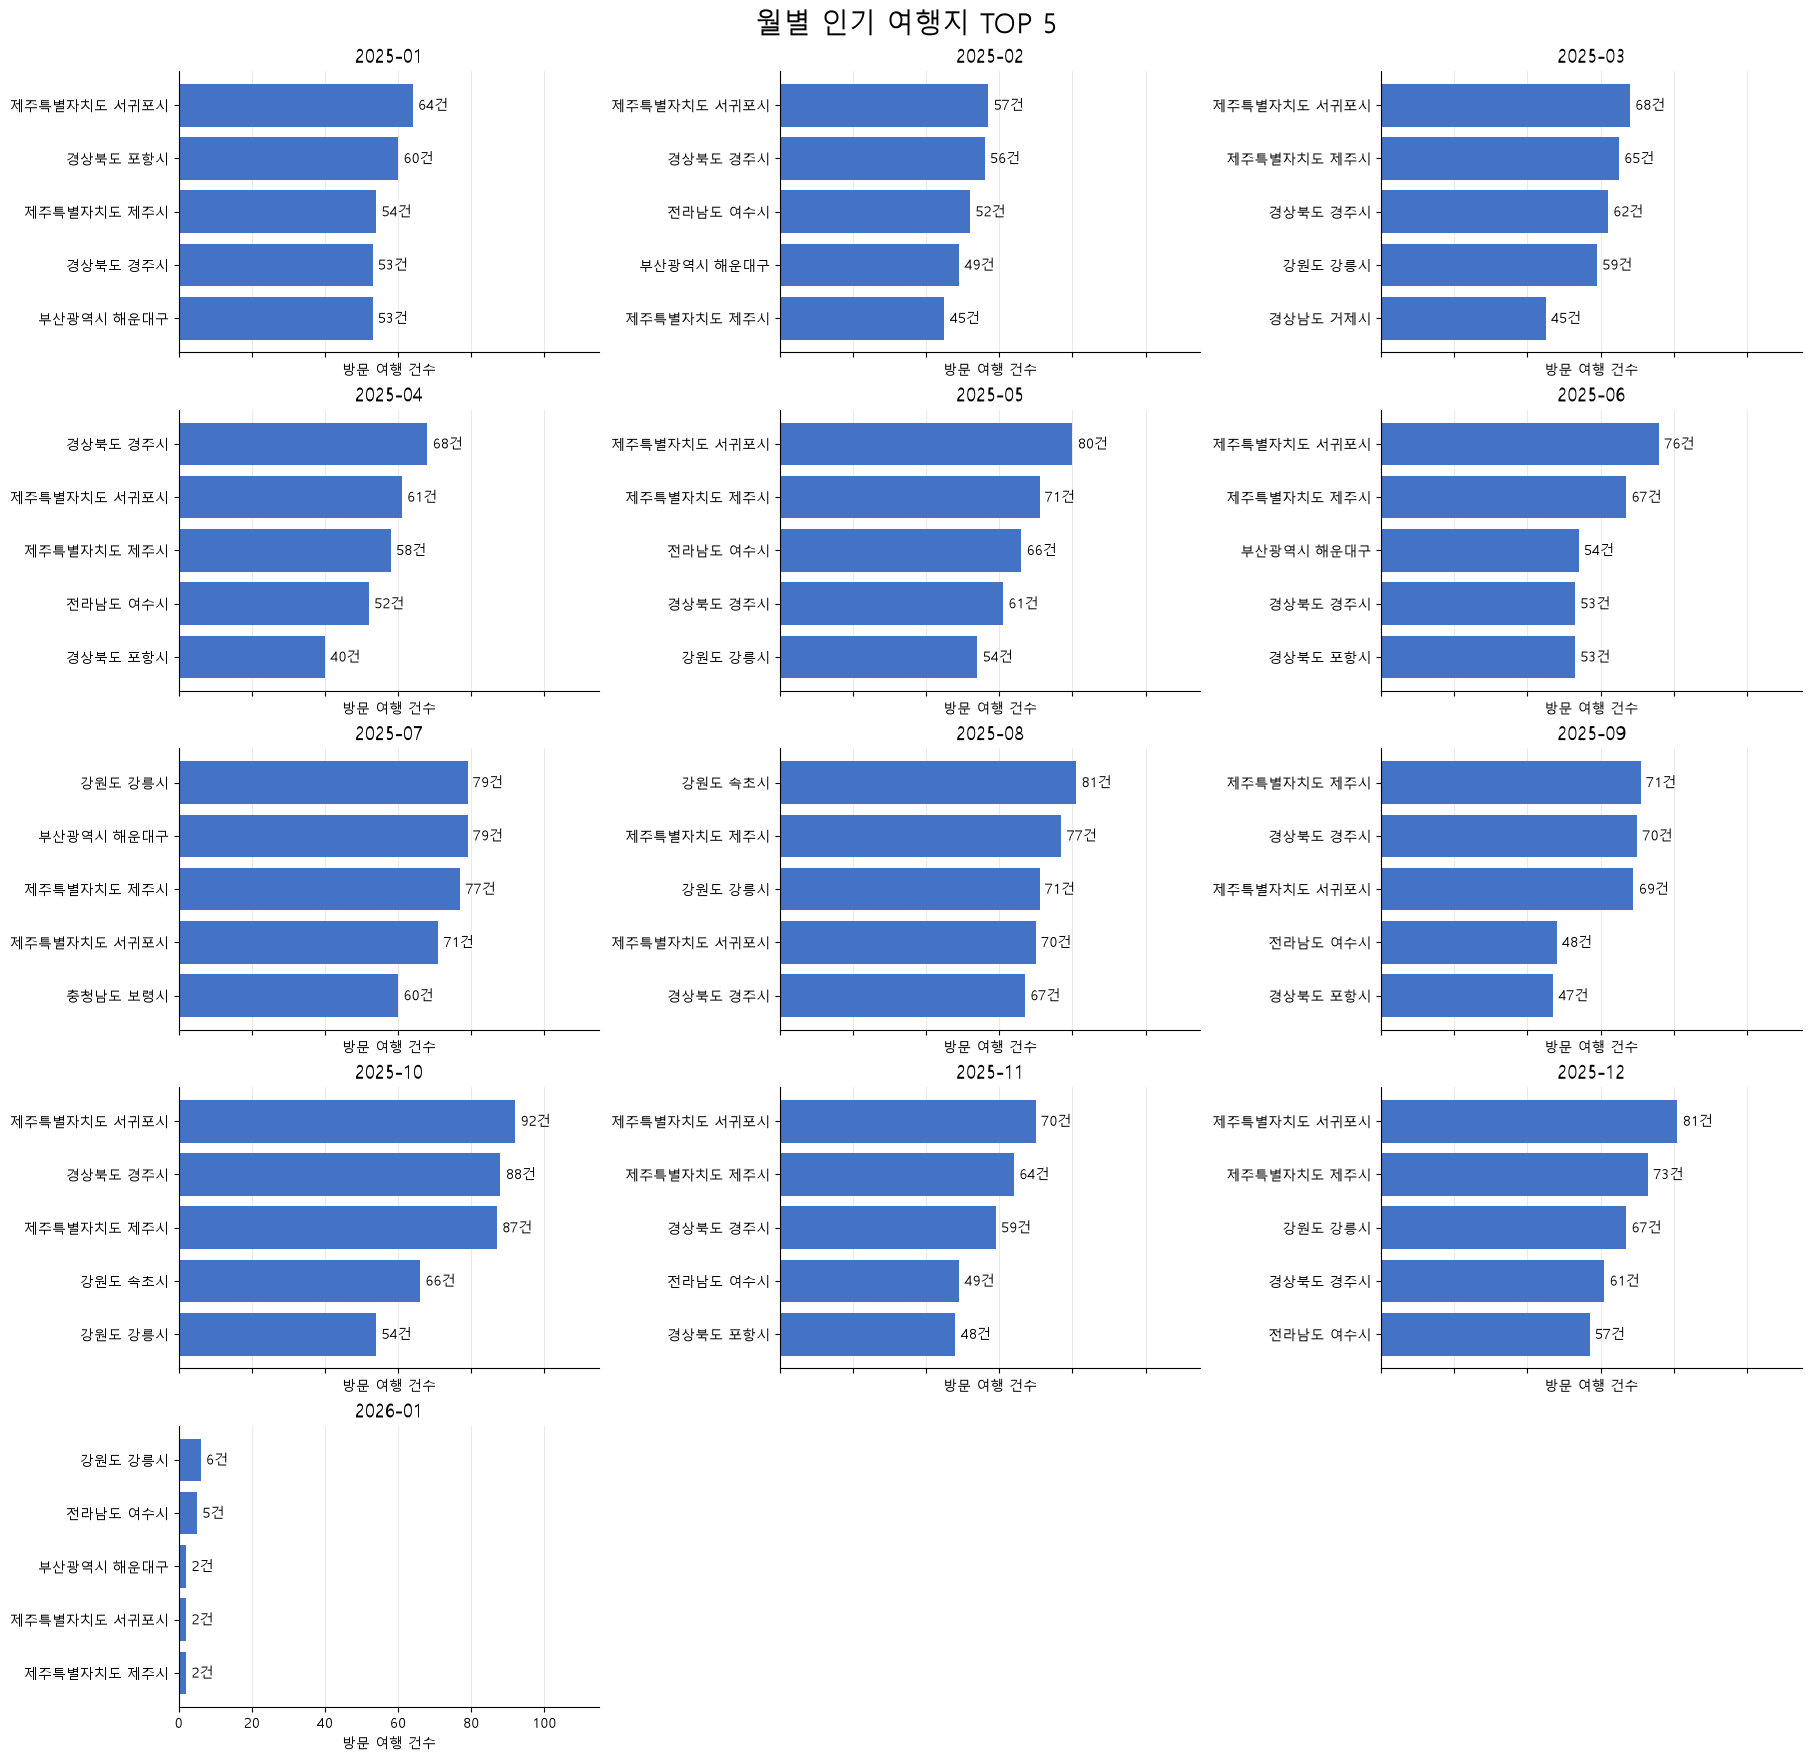

In [10]:
monthly_top5 = (
    monthly_ranking
    .sort_values(
        ["방문월", "방문여행건수", "방문지역"],
        ascending=[True, False, True],
    )
    .groupby("방문월")
    .head(5)
)

monthly_order = sorted(monthly_top5["방문월"].unique())
metric = "방문여행건수"
xlabel = "방문 여행 건수"
value_format = "%.0f건"

if monthly_top5.empty:
    print("시각화할 데이터가 없습니다.")
else:
    ncols = 3
    nrows = math.ceil(len(monthly_order) / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(18, 3.5 * nrows),
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )

    for ax, group in zip(axes.flat, monthly_order):
        subset = monthly_top5[monthly_top5["방문월"] == group]

        if subset.empty:
            ax.set_title(f"{group} - 데이터 없음")
            ax.set_axis_off()
            continue

        bars = ax.barh(subset["방문지역"], subset[metric], color=BAR_COLOR)
        ax.invert_yaxis()
        ax.bar_label(bars, fmt=value_format, padding=4)
        ax.set_title(group, fontsize=14)
        ax.set_xlabel(xlabel)
        ax.set_axisbelow(True)
        ax.grid(axis="x", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in list(axes.flat)[len(monthly_order):]:
        ax.set_visible(False)

    max_value = monthly_top5[metric].max()
    axes.flat[0].set_xlim(0, max(max_value * 1.25, 1))
    fig.suptitle("월별 인기 여행지 TOP 5", fontsize=20)
    plt.show()


이상 데이터의 원인을 파악하기 위해 전체여행건수 데이터를 출력해봅니다. 데이터 개수가 작은 것이 원인입니다

In [11]:
display(monthly_total)

,방문월,전체여행건수
0,2025-01,2637
1,2025-02,2156
2,2025-03,2190
3,2025-04,2260
4,2025-05,2603
5,2025-06,2286
6,2025-07,2333
7,2025-08,2426
8,2025-09,2227
9,2025-10,2868


결혼상태별 방문여행건수 정보를 얻기 위한 전처리 과정입니다

In [12]:
marital_data = df.dropna(
    subset=["ID", "여행차수", "혼인상태", "방문지역코드", "방문지역"]
).copy()

marital_data = marital_data.drop_duplicates(
    subset=["ID", "여행차수", "방문지역코드"]
)

marital_ranking = (
    marital_data.groupby(["혼인상태", "방문지역"])
    .size()
    .reset_index(name="방문여행건수")
)

marital_total = (
    marital_data.drop_duplicates(["ID", "여행차수", "혼인상태"])
    .groupby("혼인상태")
    .size()
    .rename("전체여행건수")
    .reset_index()
)

marital_ranking = marital_ranking.merge(marital_total, on="혼인상태")
marital_ranking["지역방문율"] = (
    marital_ranking["방문여행건수"] / marital_ranking["전체여행건수"] * 100
).round(1)

display(marital_ranking)


,혼인상태,방문지역,방문여행건수,전체여행건수,지역방문율
0,기타,강원도 속초시,1,8,12.5
1,기타,강원도 원주시,1,8,12.5
2,기타,강원도 춘천시,1,8,12.5
3,기타,경기도 김포시,1,8,12.5
4,기타,전라남도 여수시,1,8,12.5
...,...,...,...,...,...
878,이혼,충청북도 제천시,10,1147,0.9
879,이혼,충청북도 증평군,2,1147,0.2
880,이혼,충청북도 진천군,5,1147,0.4
881,이혼,충청북도 청주시,13,1147,1.1


결혼상태별로 지역 방문율 상위 5개 방문 지역을 추출하고 이를 가로 막대 그래프로 시각화합니다

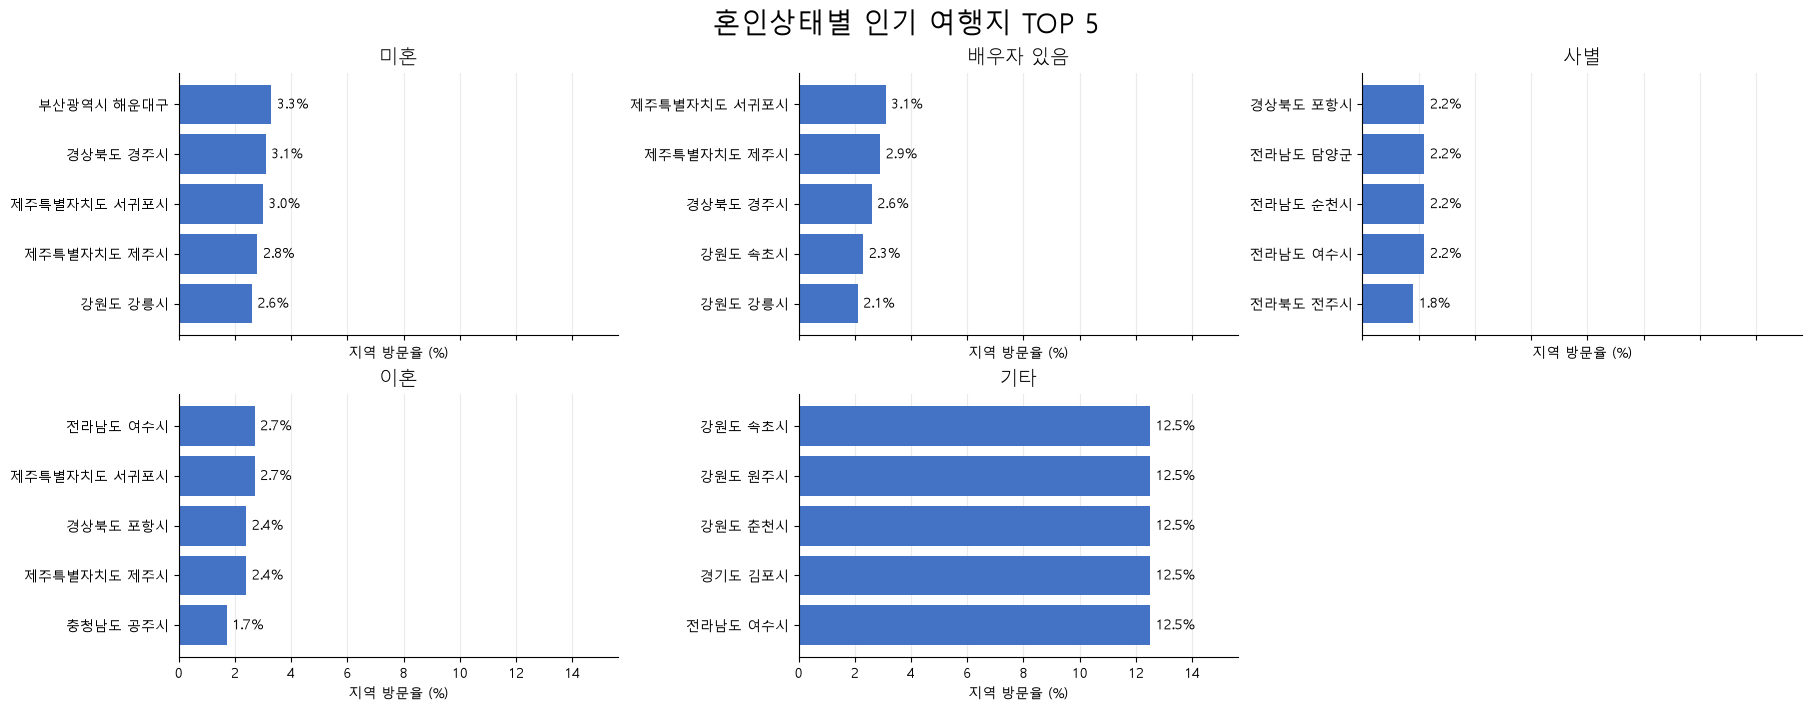

In [13]:
marital_top5 = (
    marital_ranking
    .sort_values(
        ["혼인상태", "방문여행건수", "방문지역"],
        ascending=[True, False, True],
    )
    .groupby("혼인상태")
    .head(5)
)

marital_order = ["미혼", "배우자 있음", "사별", "이혼", "기타"]
metric = "지역방문율"
xlabel = "지역 방문율 (%)"
value_format = "%.1f%%"

if marital_top5.empty:
    print("시각화할 데이터가 없습니다.")
else:
    ncols = 3
    nrows = math.ceil(len(marital_order) / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(18, 3.5 * nrows),
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )

    for ax, group in zip(axes.flat, marital_order):
        subset = marital_top5[marital_top5["혼인상태"] == group]

        if subset.empty:
            ax.set_title(f"{group} - 데이터 없음")
            ax.set_axis_off()
            continue

        bars = ax.barh(subset["방문지역"], subset[metric], color=BAR_COLOR)
        ax.invert_yaxis()
        ax.bar_label(bars, fmt=value_format, padding=4)
        ax.set_title(group, fontsize=14)
        ax.set_xlabel(xlabel)
        ax.set_axisbelow(True)
        ax.grid(axis="x", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in list(axes.flat)[len(marital_order):]:
        ax.set_visible(False)

    max_value = marital_top5[metric].max()
    axes.flat[0].set_xlim(0, max(max_value * 1.25, 1))
    fig.suptitle("혼인상태별 인기 여행지 TOP 5", fontsize=20)
    plt.show()


이상 데이터의 원인을 파악하기 위해 전체여행건수 데이터를 출력해봅니다. 데이터 개수가 작은 것이 원인입니다

In [14]:
display(marital_total)

,혼인상태,전체여행건수
0,기타,8
1,미혼,8064
2,배우자 있음,18014
3,사별,1331
4,이혼,1147
